In [61]:
import sys
sys.path.append('../../utils')
from functions import * 

In [62]:
from importlib import reload
import sys

# Path to the Leaflet repository
PATH_TO_LEAFLET_REPO = '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/'
sys.path.append(PATH_TO_LEAFLET_REPO)

In [63]:
import cell_state_asign_consistency
reload  (cell_state_asign_consistency)

<module 'cell_state_asign_consistency' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/cell_state_asign_consistency.py'>

In [64]:
import betabinomo_mix_singlecells
reload (betabinomo_mix_singlecells)

<module 'betabinomo_mix_singlecells' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/betabinomo_mix_singlecells.py'>

In [65]:
# reload load_cluster_data
import load_cluster_data
reload (load_cluster_data)

<module 'load_cluster_data' from '/gpfs/commons/home/kisaev/Leaflet/src/beta-binomial-mix/load_cluster_data.py'>

In [66]:
from importlib import reload
#from load_cluster_data import load_cluster_data
from betabinomo_mix_singlecells import *
#reload(betabinomo_mix_singlecells)
from cell_state_asign_consistency import *
#reload(cell_state_asign_consistency)
import torch
import sklearn.manifold 
import plotnine as p9
import time
# indicate plot should be small 4 by 4
import plotnine as p9
from plotnine import ggplot, geom_point, aes, stat_smooth, facet_wrap, geom_violin, theme, element_blank, geom_text, geom_bar, geom_hline
import plotnine
from tqdm import tqdm
plotnine.options.figure_size = (4, 4)
import seaborn as sns
sns.set_theme(style="whitegrid")

### Settings and Load data

In [67]:
torch.manual_seed(42)

# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

K = 10 # set to very high number 

float_type = { 
    "device" : device, 
    "dtype" : torch.float, # save memory
}

hypers = {
    "eta" : 1./K, 
    "alpha_prior" : 1., 
    "pi_prior" : 1.
}

print(hypers["eta"])

cpu
0.1


### load_cluster_data takes

In [68]:
# this folder contains input data for each tissue cell type sample
organ="Muscle"
input_files_folder="/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/"+organ+"/"

final_data, coo_counts_sparse, coo_cluster_sparse, cell_ids_conversion, junction_ids_conversion = load_cluster_data.load_cluster_data(
    input_folder = input_files_folder, has_genes="yes") 

Reading in data from folder ...
/gpfs/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/Leaflet-Intron-Clusters/Muscle/


Finished reading in data from folder ...
['mesenchymal stem cell' 'macrophage' 't cell'
 'cd8-positive, alpha-beta t cell' 'tendon cell'
 'endothelial cell of lymphatic vessel' 'capillary endothelial cell'
 'endothelial cell of artery' 'fast muscle cell'
 'skeletal muscle satellite stem cell' 'slow muscle cell'
 'endothelial cell of vascular tree' 'mature nk t cell' 'pericyte cell'
 'mesothelial cell' 'cd4-positive, alpha-beta t cell' 'smooth muscle cell'
 'erythrocyte' 'mast cell']
5004
144381
                                       cell_id  Cluster  Cluster_Counts  \
0  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
1  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
2  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      146             191   
3  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      476              28   
4  B107909_A11_S239.homo.gencode.v30.ERCC.chrM      580             177   

             junction_id             gene_id  jun

In [69]:
print("The number of junctions is: ", len(junction_ids_conversion))
print("The number of intron clusters observed is: ", len(junction_ids_conversion.Cluster.unique()))
print("The number of genes is: ", len(junction_ids_conversion.gene_id.unique()))

The number of junctions is:  144382
The number of intron clusters observed is:  28353
The number of genes is:  14159


In [70]:
# ensure that in coo_counts_sparse.shape = (n_cells, n_genes) , n_cells is the same number as cell_ids_conversion.shape = (n_cells, num_variables)
assert coo_counts_sparse.shape[0] == cell_ids_conversion.shape[0]

In [71]:
cell_index_tensor, junc_index_tensor, my_data = make_torch_data(final_data, **float_type)

The number of cells going into training data is:
5004
5004


In [72]:
# what is the breadkdown of cell types in the data 
cell_ids_conversion['cell_type'].value_counts()

mesenchymal stem cell                   1416
endothelial cell of vascular tree        731
skeletal muscle satellite stem cell      604
macrophage                               505
cd8-positive, alpha-beta t cell          487
capillary endothelial cell               412
pericyte cell                            281
cd4-positive, alpha-beta t cell          139
mature nk t cell                          88
endothelial cell of lymphatic vessel      66
fast muscle cell                          65
tendon cell                               55
t cell                                    53
slow muscle cell                          52
mast cell                                 29
smooth muscle cell                        15
endothelial cell of artery                 3
erythrocyte                                2
mesothelial cell                           1
Name: cell_type, dtype: int64

In [73]:
# set random seed
torch.manual_seed(0)

num_trials = 10 # should also be an argument that gets fed in
num_iters = 100 # should also be an argument that gets fed in

# loop over the number of trials (for now just testing using one trial but in general need to evaluate how performance is affected by number of trials)
#reload(betabinomo_mix_singlecells)

start_time = time.time()

# Running for just one K and assessing similarity across trials 

results = [ calculate_CAVI(K, my_data, float_type, hypers, init_labels = None, num_iterations = num_iters) 
           for t in range(num_trials) ]


# write the above line use fstring
print(f"This took {time.time() - start_time} seconds")

Initialize VI params
Initializing variational parameters with N = 5004 cells and J = 144382 junctions
Got the initial ELBO ^
ELBO converged @ -4831740416.0 CAVI iteration # 6 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5004 cells and J = 144382 junctions
Got the initial ELBO ^
ELBO converged @ -4831276032.0 CAVI iteration # 11 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5004 cells and J = 144382 junctions
Got the initial ELBO ^
ELBO converged @ -4831112192.0 CAVI iteration # 7 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5004 cells and J = 144382 junctions
Got the initial ELBO ^
ELBO converged @ -4831261696.0 CAVI iteration # 7 complete
Finished CAVI!
Initialize VI params
Initializing variational parameters with N = 5004 cells and J = 144382 junctions
Got the initial ELBO ^
ELBO converged @ -4831350784.0 CAVI iteration # 7 complete
Finished CAVI!
Init

In [74]:
len(results)

10

### Evaluate the learned posteriors

The trial with the highest ELBO was 7


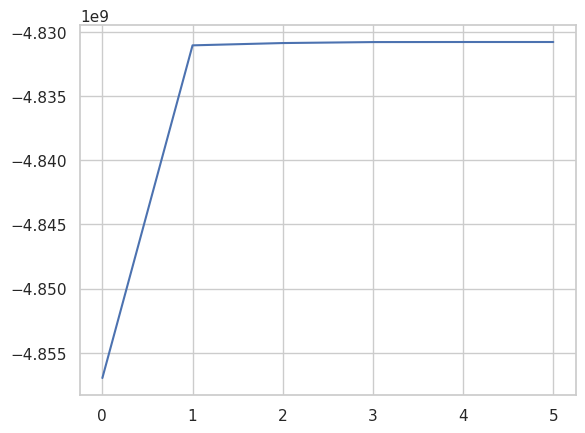

In [75]:
best = np.argmax([ g[-1][-1] for g in results ]) # final ELBO
print(f"The trial with the highest ELBO was {best}")
ALPHA_f, PI_f, GAMMA_f, PHI_f, elbos_all = results[best]
elbos_all = np.array(elbos_all)
plt.plot(elbos_all[1:]); plt.show()

In [76]:
PHI_f_plot = pd.DataFrame(PHI_f.cpu().numpy())
PHI_f_plot['cell_id'] = cell_ids_conversion["cell_type"].to_numpy()

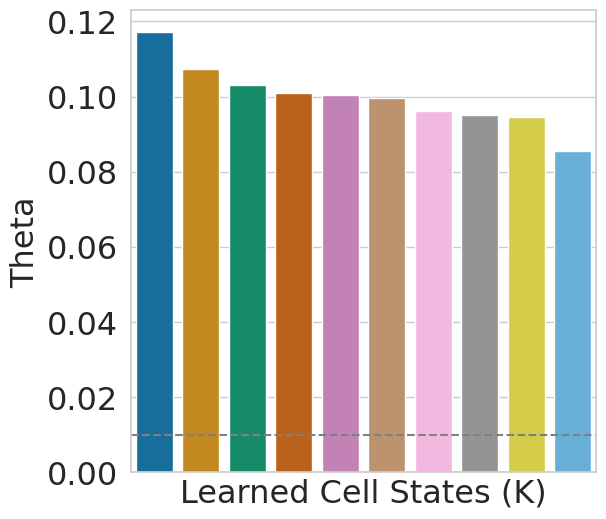

In [77]:
# How much is each cell state is used globally 

# Calculate the total sum of the tensor values
total_sum = torch.sum(GAMMA_f)

# Calculate the percentages
percentages = (GAMMA_f / total_sum) 

# Convert the tensor to a dataframe 
GAMMA_f_plot = pd.DataFrame(percentages.cpu().numpy())
# Give it a colname called theta 
GAMMA_f_plot.columns = ["theta"]
GAMMA_f_plot["cell_state"] = GAMMA_f_plot.index
GAMMA_f_plot.sort_values(by="theta", ascending=False, inplace=True)
GAMMA_f_plot["new_cell_state"] = np.arange(GAMMA_f_plot.shape[0])

sorted_cell_states = GAMMA_f_plot["new_cell_state"].astype(str)

# rename cell_state to be from 0 to K-1 based on order in sorted_cell_states
GAMMA_f_plot.head()

GAMMA_f_plot["new_cell_state"] = pd.Categorical(sorted_cell_states, sorted_cell_states.unique())
GAMMA_f_plot = GAMMA_f_plot.sort_values(by='new_cell_state')

# Create a color mapping for each unique cellassignment
unique_states = GAMMA_f_plot['new_cell_state'].unique()
palette = sns.color_palette("colorblind", len(unique_states))
color_mapping = dict(zip(unique_states, palette))

# Make barplot using sns
plt.figure(figsize=(6, 6))
sns.barplot(x="new_cell_state", y="theta", data=GAMMA_f_plot, palette=color_mapping)
plt.axhline(0.01, ls='--', color='grey')

# Make Y label say Theta and increase font of all labels and ticks
plt.ylabel("Theta", fontsize=23)
plt.xlabel("Learned Cell States (K)", fontsize=23)
plt.xticks([])
plt.yticks(fontsize=23)
plt.show()

In [78]:
final_data.cell_type.unique()

array(['capillary endothelial cell', 'endothelial cell of vascular tree',
       'pericyte cell', 'skeletal muscle satellite stem cell',
       'endothelial cell of lymphatic vessel', 'macrophage',
       'mesenchymal stem cell', 'mature nk t cell', 't cell',
       'cd4-positive, alpha-beta t cell',
       'cd8-positive, alpha-beta t cell', 'mast cell', 'tendon cell',
       'fast muscle cell', 'slow muscle cell', 'erythrocyte',
       'endothelial cell of artery', 'smooth muscle cell',
       'mesothelial cell'], dtype=object)

In [79]:
cell_types_summary=cell_ids_conversion['cell_type'].value_counts()
cell_types_summary=pd.DataFrame(cell_types_summary)
cell_types_summary.reset_index(inplace=True)
cell_types_summary.columns=['cell_type','count']
# get percentage of each cell type in the data 
cell_types_summary['percentage']=cell_types_summary['count']/cell_types_summary['count'].sum()
cell_types_summary.sort_values(by='percentage',ascending=False,inplace=True)
print(cell_types_summary)
# plot barplot similar to above with thetas 

                               cell_type  count  percentage
0                  mesenchymal stem cell   1416    0.282974
1      endothelial cell of vascular tree    731    0.146083
2    skeletal muscle satellite stem cell    604    0.120703
3                             macrophage    505    0.100919
4        cd8-positive, alpha-beta t cell    487    0.097322
5             capillary endothelial cell    412    0.082334
6                          pericyte cell    281    0.056155
7        cd4-positive, alpha-beta t cell    139    0.027778
8                       mature nk t cell     88    0.017586
9   endothelial cell of lymphatic vessel     66    0.013189
10                      fast muscle cell     65    0.012990
11                           tendon cell     55    0.010991
12                                t cell     53    0.010592
13                      slow muscle cell     52    0.010392
14                             mast cell     29    0.005795
15                    smooth muscle cell

In [80]:
# let's retain only the cell states that are used more than 1% of the time
#GAMMA_f_plot = GAMMA_f_plot[GAMMA_f_plot["theta"] > 0.01]
GAMMA_f_plot.index.values

array([1, 9, 0, 5, 6, 8, 7, 4, 2, 3])

In [81]:
# convert PHI_f to a dataframe and add a column with cell ID and cell type 
PHI_f = pd.DataFrame(PHI_f)

# Keep only cell states defined above GAMMA_f_plot.index.values
PHI_f = PHI_f.loc[:, GAMMA_f_plot.index.values]
PHI_f

,1,9,0,5,6,8,7,4,2,3
0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
4999,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
5000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
5001,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
5002,2.393772e-16,3.653383e-23,0.993445,0.006551,1.439836e-13,6.143052e-09,0.000004,1.716284e-14,6.517277e-25,6.056019e-13


In [82]:
# Add "CellState" to each column 
PHI_f.columns = ["CellState_" + str(i+1) for i in range(PHI_f.shape[1])]
PHI_f['cell_id'] = cell_ids_conversion.cell_id.values
PHI_f['cell_type'] = cell_ids_conversion.cell_type.values
PHI_f.groupby('cell_type').sum()

/scratch/ipykernel_18001/1031914918.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10
cell_type,,,,,,,,,,
capillary endothelial cell,42.132328,43.298840,43.474026,49.064552,42.105251,51.050068,32.214882,30.085701,4.049470e+01,3.807965e+01
"cd4-positive, alpha-beta t cell",9.124039,15.126693,12.110356,18.102188,19.067455,10.110761,14.094004,16.091883,1.508855e+01,1.008408e+01
"cd8-positive, alpha-beta t cell",61.001713,43.058655,56.000546,38.007240,50.650917,46.000217,59.038563,56.064877,4.013974e+01,3.703753e+01
endothelial cell of artery,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
endothelial cell of lymphatic vessel,8.000000,9.000000,5.000000,7.000000,6.000000,9.000000,7.000000,1.000000,7.000000e+00,7.000000e+00
endothelial cell of vascular tree,92.009659,98.999817,61.000011,69.000000,92.984360,69.000092,56.005978,55.000000,6.600008e+01,7.100000e+01
erythrocyte,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000e+00,0.000000e+00
fast muscle cell,28.000000,0.000000,1.000000,0.000000,18.000000,0.000000,0.000000,15.000000,3.000000e+00,0.000000e+00
macrophage,57.008648,60.000988,75.071838,61.041214,40.936066,50.002579,48.807133,43.058739,3.207124e+01,3.700156e+01


In [83]:
print("Numbrt of latent cell states kept: ", PHI_f.shape[1]-2)

Numbrt of latent cell states kept:  10


/scratch/ipykernel_18001/2520592141.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
/scratch/ipykernel_18001/2520592141.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.


{'CellState_1': ('fast muscle cell', 0.431), 'CellState_10': ('endothelial cell of artery', 0.333), 'CellState_2': ('mast cell', 0.241), 'CellState_3': ('smooth muscle cell', 0.2), 'CellState_4': ('smooth muscle cell', 0.467), 'CellState_5': ('endothelial cell of artery', 0.333), 'CellState_6': ('erythrocyte', 0.5), 'CellState_7': ('mesothelial cell', 1.0), 'CellState_8': ('slow muscle cell', 0.481), 'CellState_9': ('erythrocyte', 0.5)}


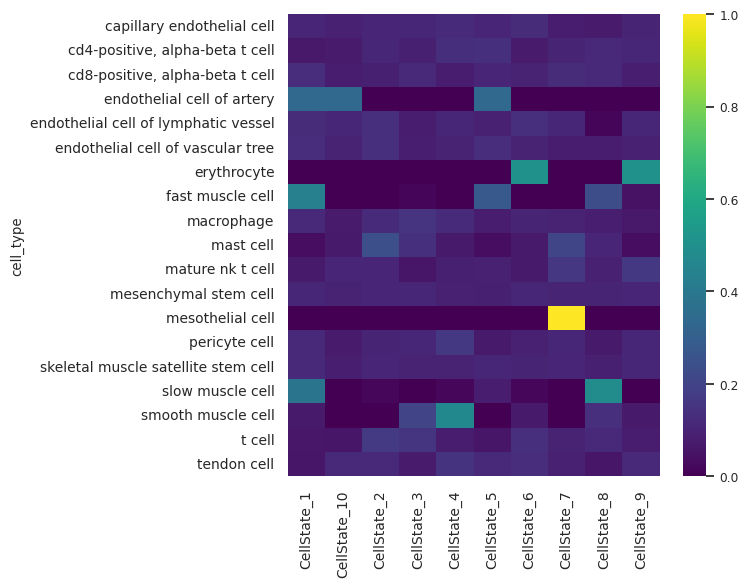

In [84]:
# group by cell_type and sum across each cellstate 
PHI_f.groupby('cell_type').sum()
sum_prop=PHI_f.groupby('cell_type').sum()/PHI_f.groupby('cell_type').count()
# remove cell_id column 
sum_prop=sum_prop.drop(columns=['cell_id'])
#masked_data = np.ma.masked_equal(sum_prop, 0)
sns.set(font_scale=0.8)  # Adjust font size for labels
# make figure bigger 
plt.figure(figsize=(6, 6))
# make font size of xtickts and yticks bigger
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)
sns.heatmap(sum_prop, annot=False, fmt=".2f", cmap='viridis')

# now let's give the cell states new labels based on what cell types they are associated with 
# go through sum_prop and for each cell state find the cell type with the highest proportion
# assign that cell type to the cell state
cell_type_labels = {}
for state in sum_prop.columns:
    max_prop = 0
    max_celltype = ''
    for celltype in sum_prop.index:
        if sum_prop.loc[celltype, state] > max_prop:
            max_prop = sum_prop.loc[celltype, state]
            max_celltype = celltype
    cell_type_labels[state] = max_celltype, round(max_prop, 3)
print(cell_type_labels)

In [85]:
# run fisher's exact test to see if the cell states are enriched for any cell types
from scipy.stats import fisher_exact

PHI_f_melt = pd.melt(PHI_f, id_vars=['cell_id', 'cell_type'], value_vars=PHI_f.columns[:-2])

# for each cell, choose cell state with highest probability
PHI_f_melt = PHI_f_melt.sort_values(by=['cell_id', 'value'], ascending=False).drop_duplicates(subset=['cell_id'])
PHI_f_melt.head()

,cell_id,cell_type,variable,value
35027,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell,CellState_7,1.000000
15010,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell,CellState_3,0.993445
40029,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,smooth muscle cell,CellState_8,1.000000
40028,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell,CellState_8,1.000000
25015,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell,CellState_5,1.000000


In [86]:
#show PHI_f without the last two columns 
PHI_f.drop(columns=['cell_id', 'cell_type'])

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10
0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...
4999,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
5000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
5001,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00
5002,2.393772e-16,3.653383e-23,0.993445,0.006551,1.439836e-13,6.143052e-09,0.000004,1.716284e-14,6.517277e-25,6.056019e-13


In [87]:
# get sum aross rows for each cell PHI_f.drop(columns=['cell_id', 'cell_type'])
PHI_f.drop(columns=['cell_id', 'cell_type']).sum(axis=1)

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
4999    1.0
5000    1.0
5001    1.0
5002    1.0
5003    1.0
Length: 5004, dtype: float32

In [126]:
top_three_cell_types = cell_ids_conversion.cell_type.value_counts()[0:8].index.values
cell_types = cell_ids_conversion['cell_type'].apply(lambda x: x if x in top_three_cell_types else 'Other').tolist()
top_three_cell_types_list = list(top_three_cell_types)
top_three_cell_types_list

['mesenchymal stem cell',
 'endothelial cell of vascular tree',
 'skeletal muscle satellite stem cell',
 'macrophage',
 'cd8-positive, alpha-beta t cell',
 'capillary endothelial cell',
 'pericyte cell',
 'cd4-positive, alpha-beta t cell']

In [127]:
PHI_f_melt.sort_values(by="value")

,cell_id,cell_type,variable,value
25355,B107909_B23_S274.homo.gencode.v30.ERCC.chrM,t cell,CellState_6,0.110851
819,B107921_L22_S243.homo.gencode.v30.ERCC.chrM,mesenchymal stem cell,CellState_1,0.115258
1845,TSP2_Muscle_diaphragm_SS2_B114671_B133329_Stro...,skeletal muscle satellite stem cell,CellState_1,0.120526
583,B107909_O16_S266.homo.gencode.v30.ERCC.chrM,"cd4-positive, alpha-beta t cell",CellState_1,0.124039
31065,B107924_H18_S222.homo.gencode.v30.ERCC.chrM,pericyte cell,CellState_7,0.128464
...,...,...,...,...
33357,TSP4_Muscle_diaphragm_SS2_B112866_B134045_Musc...,mesenchymal stem cell,CellState_7,1.000000
3334,TSP4_Muscle_diaphragm_SS2_B112866_B134045_Musc...,mesenchymal stem cell,CellState_1,1.000000
13343,TSP4_Muscle_diaphragm_SS2_B112866_B134045_Musc...,pericyte cell,CellState_3,1.000000
23344,TSP4_Muscle_diaphragm_SS2_B112866_B134045_Musc...,skeletal muscle satellite stem cell,CellState_5,1.000000


<Axes: >

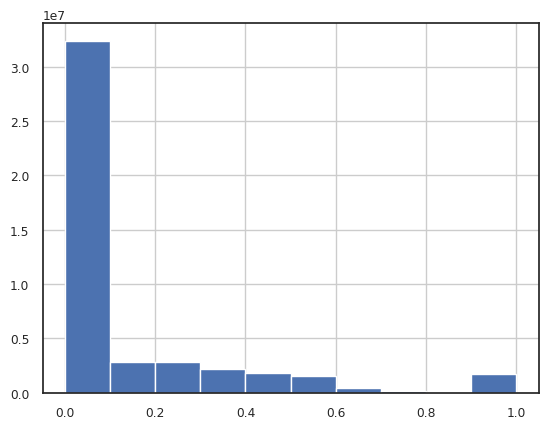

In [134]:
final_data.juncratio.hist()

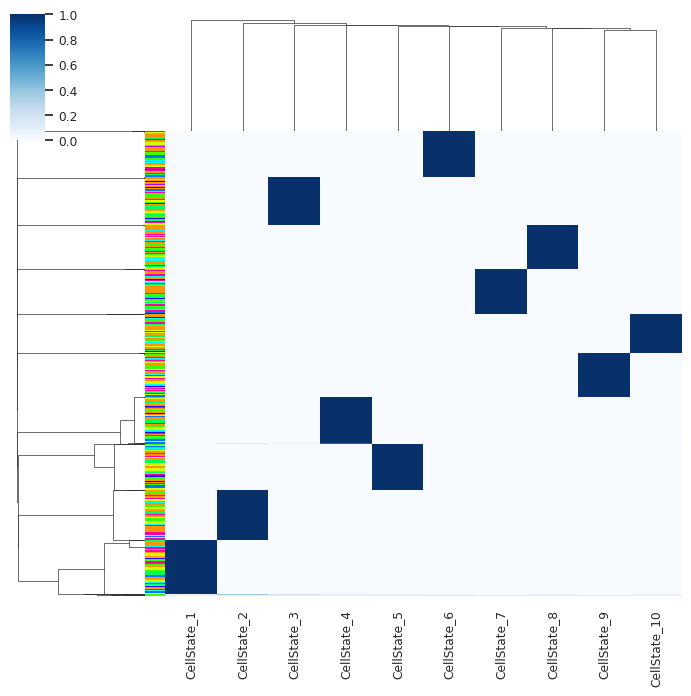

In [128]:
# Create a color palette for the cell types
cell_type_palette = sns.color_palette("hsv", len(top_three_cell_types_list) + 1)

# Map cell types to colors
row_colors = [cell_type_palette[top_three_cell_types_list.index(ct)] if ct in top_three_cell_types_list else cell_type_palette[-1] for ct in cell_types]

# Generate the clustermap with row colors
sns.clustermap(PHI_f.drop(columns=['cell_id', 'cell_type']), cmap="Blues", figsize=(7, 7),
              row_colors=row_colors,  # Using a list instead of a DataFrame
               yticklabels=False)  # Hide y-axis labels for clarity

plt.show()

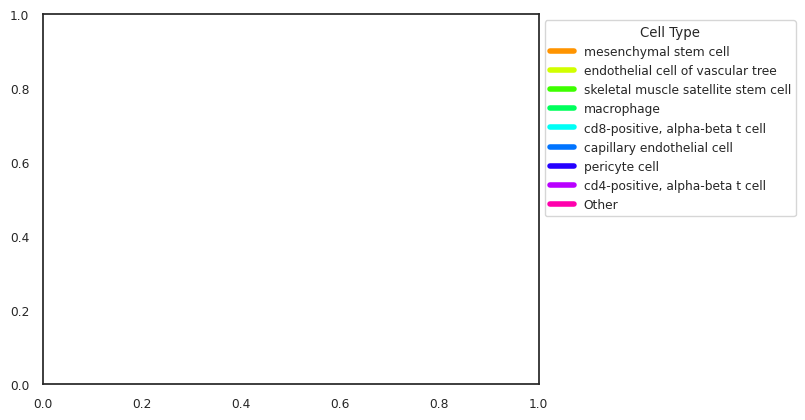

In [129]:
legend_handles = [plt.Line2D([0], [0], color=color, lw=4) for color in cell_type_palette]
legend_labels = top_three_cell_types_list + ['Other']

# Add the legend to the plot
plt.legend(handles=legend_handles, labels=legend_labels, title='Cell Type',
           bbox_to_anchor=(1, 1), loc='upper left')

## Do differential junction analysis 

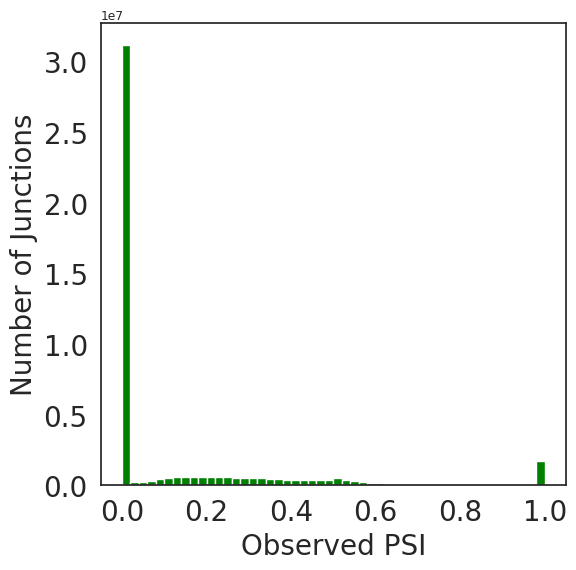

In [135]:
# plot histogram of observed junction usage ratios
plt.figure(figsize=(6, 6))
# make background white
sns.set_style("white")
plt.hist(final_data['juncratio'], bins=50, color='green')
plt.xlabel("Observed PSI", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [136]:
juncs_probs = ALPHA_f / (ALPHA_f+PI_f)   
juncs_probs.shape

torch.Size([144382, 10])

In [137]:
alpha_plus_pi = ALPHA_f+PI_f
alpha_plus_pi.shape

torch.Size([144382, 10])

In [138]:
# Create boolean mask from tensor1
mask = alpha_plus_pi >= 10

# Apply the mask to tensor2 to get filtered values
filtered_values = juncs_probs[mask]

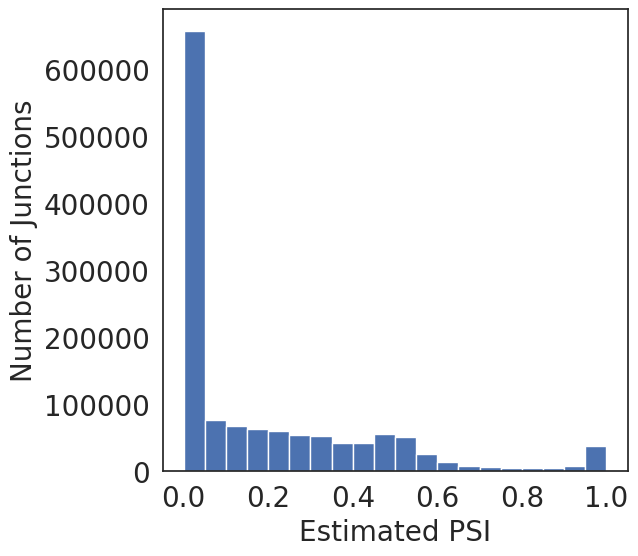

In [139]:
plt.figure(figsize=(6, 6))
# Plot the values
plt.hist(filtered_values.numpy(), bins=20)  # Assuming you want a histogram, adjust as needed
plt.xlabel('Estimated PSI', fontsize=20)
# Set y-label with larger font size (if you need it)
plt.ylabel('Number of Junctions', fontsize=20)  
# Increase tick label size
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.show()

In [140]:
juncs_probs_df = pd.DataFrame(juncs_probs, columns = range(K))
# add "cell_state" to each column name 
juncs_probs_df.columns = ["cell_state_" + str(col+1) for col in juncs_probs_df.columns]
juncs_probs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
# convert to juncs_probs to pandas dataframe and calculate mean and std across cell states/topics
juncs_probs_df["junction_id"] = junction_ids_conversion.junction_id.values

In [141]:
# calculate sd deviation for each junction for cell states 0 to 19 
juncs_probs_df["sd"] = juncs_probs_df.iloc[:,0:K].std(axis=1)

In [142]:
juncs_probs_df

,cell_state_1,cell_state_2,cell_state_3,cell_state_4,cell_state_5,cell_state_6,cell_state_7,cell_state_8,cell_state_9,cell_state_10,junction_id_index,junction_id,sd
0,0.477249,0.519353,0.484939,0.506055,0.470052,0.482822,0.451666,0.488177,0.497720,0.475265,0,10_1000868_1000947,0.019115
1,0.397296,0.347716,0.361188,0.381413,0.377739,0.340685,0.388782,0.341238,0.412241,0.366117,1,10_1001013_1005817,0.024330
2,0.000099,0.013850,0.000092,0.004146,0.001448,0.000117,0.007769,0.007236,0.006638,0.011813,2,10_1001013_1007017,0.004993
3,0.000099,0.004262,0.000092,0.000173,0.000097,0.000117,0.002554,0.000087,0.000113,0.000094,3,10_1001013_1008957,0.001448
4,0.064914,0.063585,0.147805,0.060606,0.092376,0.057165,0.093850,0.075745,0.022195,0.063762,4,10_100152352_100154859,0.032700
...,...,...,...,...,...,...,...,...,...,...,...,...,...
144377,0.001898,0.043561,0.002146,0.007853,0.024490,0.030612,0.001681,0.020101,0.027174,0.005587,144377,Y_57208979_57209531,0.014738
144378,0.396584,0.399621,0.512876,0.293194,0.400000,0.323129,0.331092,0.623116,0.456522,0.320298,144378,Y_57209354_57209531,0.102104
144379,0.398724,0.603746,0.405864,0.423077,0.411765,0.476744,0.448669,0.386441,0.406926,0.458268,144379,Y_57210792_57211551,0.063636
144380,0.036683,0.001441,0.001543,0.036538,0.001730,0.038055,0.001901,0.001695,0.004329,0.012598,144380,Y_57210792_57211760,0.016522


In [143]:
# get likelihood ratio/bayes factor score for ALL junctions 
# let's compare just state X and Y

scores_all_juncs = []
for junc_index in range(juncs_probs.shape[0]):
    a = ALPHA_f[junc_index, ]
    b = PI_f[junc_index, ]
    scores_all_juncs.append(score(a, b).item())

# turn scores_all_juncs into dataframe and add junction_id_index as a column
scores_all_juncs_df = pd.DataFrame(scores_all_juncs, columns = ["score"])
scores_all_juncs_df["junction_id_index"] = junction_ids_conversion.junction_id_index.values
scores_all_juncs_df.sort_values(by="score", ascending=False).head(10)

,score,junction_id_index
137864,53237.812500,137864
137865,53237.812500,137865
137869,34027.015625,137869
31869,32546.250000,31869
31865,32462.312500,31865
61580,30999.812500,61580
61574,29351.687500,61574
61567,28077.937500,61567
36474,26550.906250,36474
36472,26389.648438,36472


In [100]:
# Compute the logistic score
scores_all_juncs_df["logistic_score"] = 1 / (1 + np.exp(-scores_all_juncs_df["score"]))

# Compute the Bayesian q-value for FDR
scores_all_juncs_df["q_value"] = 1 - scores_all_juncs_df["logistic_score"]
scores_all_juncs_df["significance"] = np.where(scores_all_juncs_df["q_value"] < 0.05, "yes", "no")

In [101]:
scores_all_juncs_df

,score,junction_id_index,logistic_score,q_value,significance
0,15.179688,0,1.0,2.555909e-07,yes
1,80.945312,1,1.0,0.000000e+00,yes
2,237.871094,2,1.0,0.000000e+00,yes
3,83.027344,3,1.0,0.000000e+00,yes
4,250.091797,4,1.0,0.000000e+00,yes
...,...,...,...,...,...
144377,35.084351,144377,1.0,6.661338e-16,yes
144378,69.190918,144378,1.0,0.000000e+00,yes
144379,35.831055,144379,1.0,2.220446e-16,yes
144380,61.282715,144380,1.0,0.000000e+00,yes


In [102]:
scores_all_juncs_df = scores_all_juncs_df.merge(junction_ids_conversion, on="junction_id_index").sort_values(by="score", ascending=False)

In [103]:
def quick_junc_plot(junc, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["junction_id_index"] == junc]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Junction:" + str(junc) + " Gene: " + simple_data_junc["gene_id"].values[0])
    # set x axis label to "Junction Usage Ratio (PSI)"
    plt.xlabel("Junction Usage Ratio (PSI)")
    plt.show()

In [104]:
def quick_clust_plot(clust, simple_data, gene_name=None):
    simple_data_junc = simple_data[simple_data["Cluster"] == clust]
    # make violin plot with jitter 
    print(simple_data_junc.cell_type.value_counts())

    # how many cells from each cell type? let's only keep cell types with more than 10 cells here otherwise violin plot doesn't make sense
    # Modify y-tick labels to show only the portion after "Myeloid_" and split "oligodendrocyte_precursor_cell" over two lines

    # set figure size to be 6 by 7 
    plt.figure(figsize=(6, 6))
    sns.violinplot(data = simple_data_junc, x = "junc_ratio", y = "cell_type", hue="junction_id_index")
    # make xlim -1 to 1.1
    plt.xlim(-0.2, 1.2)
    # add sample_label to title 
    if gene_name:
        plt.title("Cluster:" + str(clust) + " Gene: " + simple_data_junc["gene_id"].values[0], fontsize=16)
    # set x axis label to "Junction Usage Ratio (PSI)"
    # increase font size of title and xaxis and yaxis labels
    plt.xlabel("Observed PSI", fontsize=16)
    
    # Modify y-tick labels to show only the portion after "Myeloid_"
    plt.ylabel("Cell Type", fontsize=20)
    plt.xlabel("Observed PSI", fontsize=20)
    # increase font size of xticks and yticks
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=16)
    plt.show()

In [105]:
simple_data = final_data[["cell_id_index", "cell_type", "junction_id_index", "junc_count", "cluster_count"]]
simple_data = simple_data.merge(junction_ids_conversion, on="junction_id_index")
simple_data["junc_ratio"] = simple_data["junc_count"] / simple_data["cluster_count"]
simple_data.head()

,cell_id_index,cell_type,junction_id_index,junc_count,cluster_count,junction_id,Cluster,gene_id,junc_ratio
0,0,capillary endothelial cell,8529,32.0,264,11_20387774_20388018,64526,ENSG00000185238.13,0.121212
1,2,endothelial cell of vascular tree,8529,12.0,173,11_20387774_20388018,64526,ENSG00000185238.13,0.069364
2,43,endothelial cell of vascular tree,8529,6.0,60,11_20387774_20388018,64526,ENSG00000185238.13,0.100000
3,88,endothelial cell of vascular tree,8529,9.0,158,11_20387774_20388018,64526,ENSG00000185238.13,0.056962
4,252,endothelial cell of vascular tree,8529,102.0,240,11_20387774_20388018,64526,ENSG00000185238.13,0.425000


In [106]:
# add percentile rank of score for each junction
scores_all_juncs_df["percentile_rank"] = scores_all_juncs_df["score"].rank(pct=True)
scores_all_juncs_df

,score,junction_id_index,logistic_score,q_value,significance,junction_id,Cluster,gene_id,percentile_rank
137864,53237.812500,137864,1.000000e+00,0.0,yes,9_35682163_35684245,56848,ENSG00000198467.16,0.999997
137865,53237.812500,137865,1.000000e+00,0.0,yes,9_35683241_35684245,56848,ENSG00000198467.16,0.999997
137869,34027.015625,137869,1.000000e+00,0.0,yes,9_35684807_35685268,56850,ENSG00000198467.16,0.999986
31869,32546.250000,31869,1.000000e+00,0.0,yes,15_63064142_63065895,80924,ENSG00000140416.24,0.999979
31865,32462.312500,31865,1.000000e+00,0.0,yes,15_63062645_63064063,80924,ENSG00000140416.24,0.999972
...,...,...,...,...,...,...,...,...,...
142407,-36.000000,142407,2.319523e-16,1.0,no,X_2720424_2722626,112295,ENSG00000002586.20,0.000028
142410,-36.000000,142410,2.319523e-16,1.0,no,X_2722674_2723313,112295,ENSG00000002586.20,0.000028
53926,-36.000000,53926,2.319523e-16,1.0,no,19_41869214_41869698,100052,ENSG00000105372.8,0.000028
138940,-37.000000,138940,8.533048e-17,1.0,no,9_73160376_73160802,52712,ENSG00000135046.14,0.000014


In [107]:
# check wd 
os.getcwd()

'/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien/Leaflet'

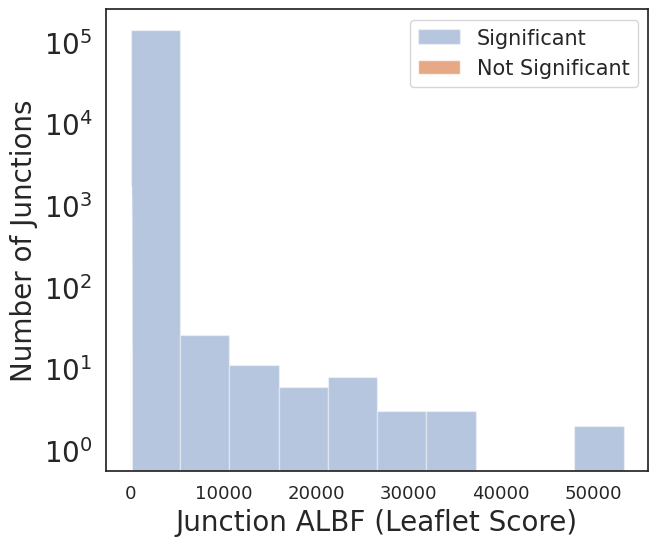

In [108]:
# Assuming you have significance data in scores_all_juncs_df
significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "yes"]["score"]
not_significant = scores_all_juncs_df[scores_all_juncs_df["significance"] == "no"]["score"]

plt.figure(figsize=(7, 6))

# Plot histograms
plt.hist(significant, bins=10, label='Significant', log=True, alpha=0.4)
plt.hist(not_significant, bins=10, label='Not Significant', log=True, alpha=0.7)

# Adjust labels, legend, and ticks
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)
plt.legend(loc='upper right', fontsize=15)

plt.show()


In [109]:
# only show scores for junctions that had decent certainty for ALPHA+BETA  
# turn alpha_plus_pi into dataframe 
alpha_plus_pi_df = pd.DataFrame(alpha_plus_pi, columns = range(K))
alpha_plus_pi_df["junction_id_index"] = alpha_plus_pi_df.index
# now melt alpha_plus_pi_df 
alpha_plus_pi_df_melt = pd.melt(alpha_plus_pi_df, id_vars=['junction_id_index'], value_vars=alpha_plus_pi_df.columns[:-1])
# rename columns to be "cell_state" and "alpha_plus_pi"
alpha_plus_pi_df_melt.columns = ["junction_id_index", "cell_state", "alpha_plus_pi"]
alpha_plus_pi_df_melt.head()

,junction_id_index,cell_state,alpha_plus_pi
0,0,0,7736.0
1,1,0,10058.0
2,2,0,10058.0
3,3,0,10058.0
4,4,0,9320.0


In [110]:
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

The number of junctions in the dataset is: 144382


In [111]:
# find the 10th, 20th, 30th... percentiels of alpha_plus_pi
alpha_plus_pi_df_melt["percentile_rank"] = alpha_plus_pi_df_melt["alpha_plus_pi"].rank(pct=True)
# subset dataframe to include only junctions with alpha_plus_pi >= 10
alpha_plus_pi_df_melt = alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["alpha_plus_pi"] >= 50]
print("The number of junctions in the dataset is: " + str(alpha_plus_pi_df_melt.junction_id_index.nunique()))

The number of junctions in the dataset is: 143224


In [112]:
scores_all_juncs_df = scores_all_juncs_df[scores_all_juncs_df["junction_id_index"].isin(alpha_plus_pi_df_melt.junction_id_index.unique())]

(array([1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04, 1.e+05, 1.e+06,
        1.e+07]),
 [Text(0, 0.1, '$\\mathdefault{10^{-1}}$'),
  Text(0, 1.0, '$\\mathdefault{10^{0}}$'),
  Text(0, 10.0, '$\\mathdefault{10^{1}}$'),
  Text(0, 100.0, '$\\mathdefault{10^{2}}$'),
  Text(0, 1000.0, '$\\mathdefault{10^{3}}$'),
  Text(0, 10000.0, '$\\mathdefault{10^{4}}$'),
  Text(0, 100000.0, '$\\mathdefault{10^{5}}$'),
  Text(0, 1000000.0, '$\\mathdefault{10^{6}}$'),
  Text(0, 10000000.0, '$\\mathdefault{10^{7}}$')])

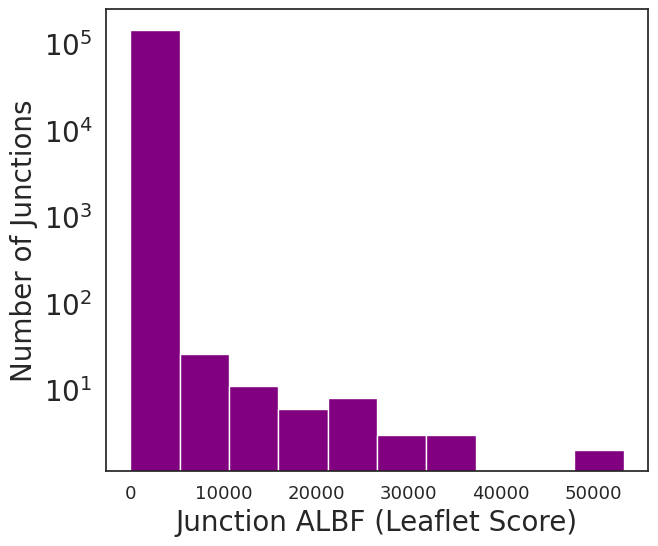

In [113]:
# make a histogram of the scores_all_juncs_df
plt.figure(figsize=(7, 6))
plt.hist(scores_all_juncs_df["score"], bins=10, color="purple", log=True)
plt.xlabel("Junction ALBF (Leaflet Score)", fontsize=20)
plt.ylabel("Number of Junctions", fontsize=20)
plt.xticks(fontsize=13)
plt.yticks(fontsize=20)

In [114]:
# make a version of the plot that shows that learned junction proportions across cell states 
from scipy.stats import beta

def quick_posterior_junc_plot(junc, ALPHAs, PIs, cell_states=None):
    
    junc_a = ALPHAs[junc, ]
    junc_b = PIs[junc, ]

    if cell_states:
        junc_a = junc_a[cell_states]
        junc_b = junc_b[cell_states]

    # Define a list of colors for the plot
    colors = ['r', 'g', 'b', 'c', 'm', 'y', 'k']  # Add more colors if needed

    # Create a figure and axis for the plot with size 6x6
    fig, ax = plt.subplots(figsize=(5, 5))

    print(junc_a, junc_b)
    
    # Loop through each cell state and plot its beta distribution with a unique color
    for j, (a, b) in enumerate(zip(junc_a, junc_b)):
        
        x = np.linspace(beta.ppf(0.01, a, b),
                        beta.ppf(0.99, a, b), 100)
        
        color = colors[j % len(colors)]  # Cycle through colors if more cell states than colors
        label = f'Cell State {j + 1}'
        
        ax.plot(x, beta.pdf(x, a, b),
                color + '-', lw=2, alpha=0.6, label=label)
        
    # Add labels and legend with increased font size
    ax.set_xlabel('PSI', fontsize=20)
    ax.set_ylabel('Probability Density', fontsize=20)
    ax.set_title('Beta Distributions for junction ' + str(junc), fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=20)
    
    # Place the legend to the right of the plot
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
    plt.show()


tensor([1072., 2889.]) tensor([1079., 3069.])


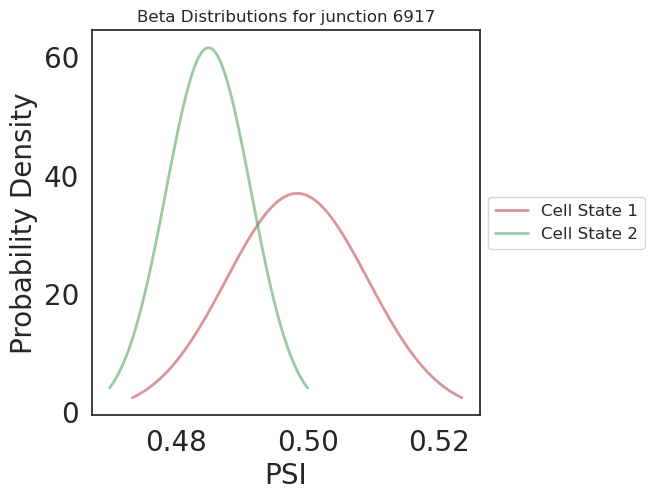

In [115]:
quick_posterior_junc_plot(6917, ALPHA_f, PI_f, cell_states=[0,6])

In [116]:
alpha_plus_pi_df_melt[alpha_plus_pi_df_melt["junction_id_index"] == 6917]

,junction_id_index,cell_state,alpha_plus_pi,percentile_rank
6917,6917,0,2151.0,0.538645
151299,6917,1,4001.0,0.641613
295681,6917,2,7397.0,0.733722
440063,6917,3,2309.0,0.550955
584445,6917,4,3222.0,0.606883
728827,6917,5,3640.0,0.626667
873209,6917,6,5958.0,0.702508
1017591,6917,7,2843.0,0.585750
1161973,6917,8,5593.0,0.693050
1306355,6917,9,4024.0,0.642603


endothelial cell of vascular tree       85
mesenchymal stem cell                   78
skeletal muscle satellite stem cell     40
cd8-positive, alpha-beta t cell         25
capillary endothelial cell              23
macrophage                              20
cd4-positive, alpha-beta t cell         13
mature nk t cell                        11
slow muscle cell                         8
pericyte cell                            7
endothelial cell of lymphatic vessel     5
tendon cell                              5
mast cell                                3
fast muscle cell                         3
t cell                                   2
Name: cell_type, dtype: int64


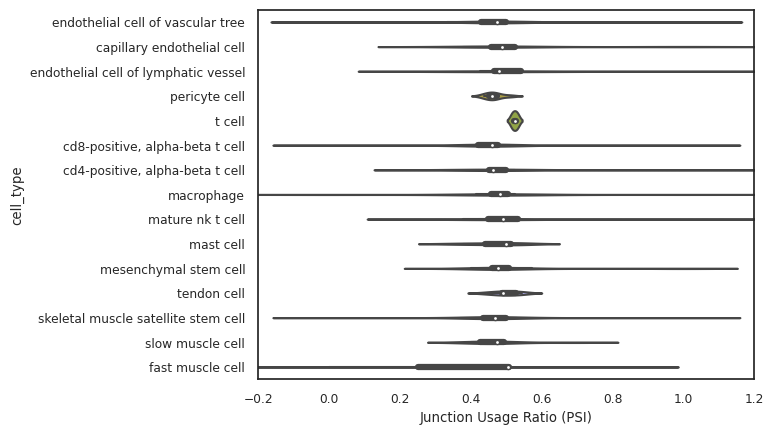

In [117]:
quick_junc_plot(6917, simple_data)

tensor([1613., 1185., 1275.,  776.,  598., 1160., 1045., 1350., 1243., 1247.]) tensor([1986., 1287., 1364., 1048.,  704., 1363., 1454., 1398., 1529., 1266.])


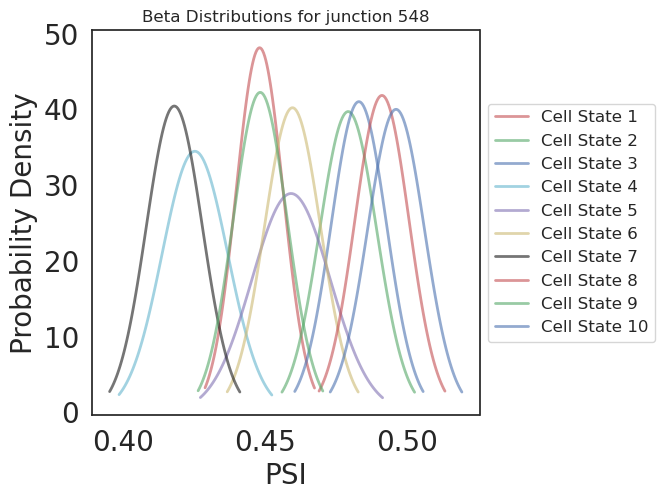

In [118]:
quick_posterior_junc_plot(548, ALPHA_f, PI_f)

In [119]:
PHI_f

,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,CellState_10,cell_id,cell_type
0,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,B107830_A10_S62.homo.gencode.v30.ERCC.chrM,capillary endothelial cell
1,0.000000e+00,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,B107830_A11_S63.homo.gencode.v30.ERCC.chrM,capillary endothelial cell
2,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,B107830_A12_S64.homo.gencode.v30.ERCC.chrM,endothelial cell of vascular tree
3,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,B107830_A13_S65.homo.gencode.v30.ERCC.chrM,capillary endothelial cell
4,0.000000e+00,0.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,B107830_A16_S68.homo.gencode.v30.ERCC.chrM,capillary endothelial cell
...,...,...,...,...,...,...,...,...,...,...,...,...
4999,0.000000e+00,0.000000e+00,0.000000,0.000000,1.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell
5000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell
5001,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000e+00,0.000000e+00,0.000000e+00,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,smooth muscle cell
5002,2.393772e-16,3.653383e-23,0.993445,0.006551,1.439836e-13,6.143052e-09,0.000004,1.716284e-14,6.517277e-25,6.056019e-13,TSP4_Muscle_rectusabdominus_SS2_B114997_B13404...,mesenchymal stem cell


In [120]:
# save cell assignments to file for downstream analysis
output_dir = '/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/'

# BBmixture model cell assignments
output_file = os.path.join(output_dir, 'Leaflet_BBmixture.csv')
PHI_f.to_csv(output_file, index=True, header=True)
print('Saved Leaflet latent cell states to {}'.format(output_file))

Saved Leaflet latent cell states to /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv
